## Questions
1. **Is there a correlation between rent prices and property size in São Paulo?**
2. **If so, what is a function to predict rent based on the size of the property?**

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import copy
%matplotlib inline

### Import database

In [2]:
df = pd.read_csv("./data/house_prices.csv")
df.head()

,address,district,area,bedrooms,garage,type,rent,total
0,Rua Herval,Belenzinho,21,1,0,Studio e kitnet,2400,2939
1,Avenida São Miguel,Vila Marieta,15,1,1,Studio e kitnet,1030,1345
2,Rua Oscar Freire,Pinheiros,18,1,0,Apartamento,4000,4661
3,Rua Júlio Sayago,Vila Ré,56,2,2,Casa em condomínio,1750,1954
4,Rua Barata Ribeiro,Bela Vista,19,1,0,Studio e kitnet,4000,4654


### Summary 
- Address: The address of the property
- District: The district where the property is located
- Area: The area of the property in square meters
- Bedrooms: The number of bedrooms in the property
- Garage: The number of parking spaces available in the property
- Rent: The monthly rent of the property
- Type: The type of the property (apartment, house, etc.)
- Total: The total cost of the property including rent, taxes, and other fees.

### Exploratory analisys

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11657 entries, 0 to 11656
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   address   11657 non-null  str  
 1   district  11657 non-null  str  
 2   area      11657 non-null  int64
 3   bedrooms  11657 non-null  int64
 4   garage    11657 non-null  int64
 5   type      11657 non-null  str  
 6   rent      11657 non-null  int64
 7   total     11657 non-null  int64
dtypes: int64(5), str(3)
memory usage: 728.7 KB


In [4]:
df.describe()

,area,bedrooms,garage,rent,total
count,11657.000000,11657.000000,11657.000000,11657.000000,11657.000000
mean,84.655658,1.966286,1.060393,3250.814789,4080.030625
std,74.020536,0.931313,1.132349,2650.711557,3352.480274
min,0.000000,0.000000,0.000000,500.000000,509.000000
25%,40.000000,1.000000,0.000000,1590.000000,1996.000000
50%,60.000000,2.000000,1.000000,2415.000000,3057.000000
75%,96.000000,3.000000,2.000000,3800.000000,4774.000000
max,580.000000,6.000000,6.000000,25000.000000,28700.000000


In [5]:
df[df.duplicated()].count()

address     0
district    0
area        0
bedrooms    0
garage      0
type        0
rent        0
total       0
dtype: int64

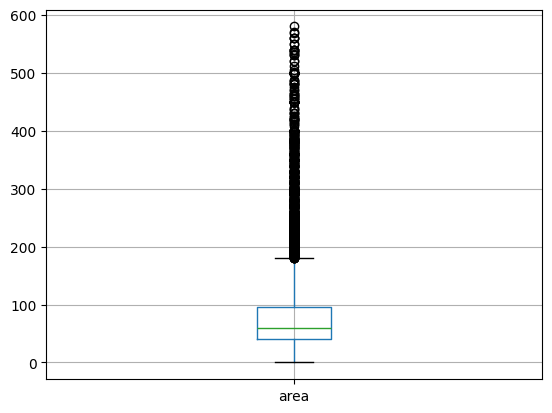

In [6]:
df.boxplot(column='area')
plt.show()

In [7]:
lower_limit = df['area'].quantile(0.1)
upper_limit = df['area'].quantile(0.9)
df_cleaned = df[(df['area'] >= lower_limit) & (df['area'] <= upper_limit)]

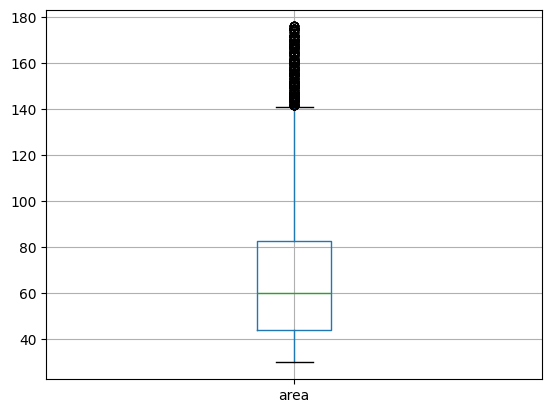

In [8]:
df_cleaned.boxplot(column='area')
plt.show()

## 1. Is there a correlation between rent prices and property size in São Paulo?

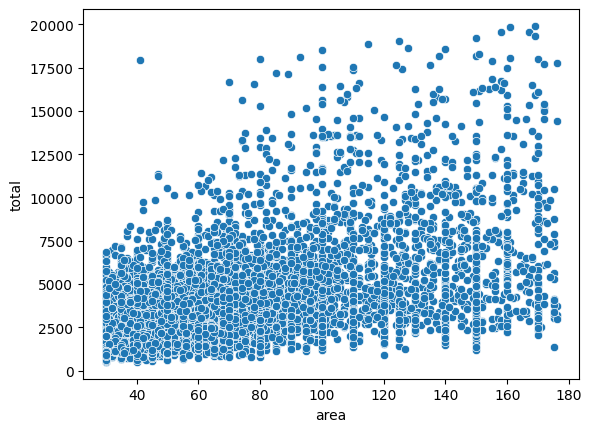

In [9]:
sns.scatterplot(data=df_cleaned, x='area', y='total')
plt.show()

**The graphic above shows that it seems to exist some correlation between rent and property size.**

To validate that, it's a nice idea to implement the pearson correlation coeficient, to verify if there is actual a correlation between size property and rent price.

In [10]:
corr = df_cleaned[['area', 'total']].corr(method='pearson')
corr

,area,total
area,1.00000,0.53644
total,0.53644,1.00000


### Conclusion
**- As it can be seen above, the pearson correlation coefficient is about 0.5, this number indicates a moderate positive linear relationship between rent price and size property.**

**Thus, the dataset can be fitted in a linear regression model to predict property rent values**

---

## 2. What is a function to predict rent based on the size of the property?
### As can be seen in the graph, it's reasonable to say that a linear function can estimate a rent amount, with that, a linear regression model can be implemented to the data to calculate the linear function.

## Defining functions for compute linear regression

### Cost function
- The linear regression cost function is defined by the following formula:

  #### $J(\overrightarrow{w}, b)\frac{1}{2m}\sum_{i=0}^{m-1}(f_{\overrightarrow{w}, b}(\overrightarrow{x}^{(i)}) - y^{(i)})^{2}$

In [11]:
def compute_linear_reg_cost(X, y, w, b):
    """
    INPUT:
    X (np.ndarray(m,n)):training data examples, m:number of training ex, n:number of features
    y (np.ndarray(m,), Scalar):training target
    w (np.ndarray, Scalar): parameters values of the model
    b (Scalar): parameter value of the model

    OUTPUT:
    total_cost (Scalar): Total cost of linear function
    """
    
    total_cost = 0
    m = X.shape[0]
    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        total_cost += ((f_wb - y[i]) ** 2)
        
    total_cost = total_cost / (2 * m)

    return total_cost

### Gradient function
Gradient formula of the J cost function

- #### dj_dw = $\frac{1}{m}\sum_{i=0}^{m-1}(f_{\overrightarrow{w}, b}(\overrightarrow{x}^{(i)}) - y^{(i)})x^{(i)}$
- #### dj_db = $\frac{1}{m}\sum_{i=0}^{m-1}(f_{\overrightarrow{w}, b}(\overrightarrow{x}^{(i)}) - y^{(i)})$

In [12]:
def compute_linear_reg_gradient(X, y, w, b):
    """
    X (np.ndarray(m,n)):training data examples, m:number of training ex, n:number of features
    y (np.ndarray(m,), Scalar):training target
    w (np.ndarray, Scalar): parameters values of the model
    b (Scalar): parameter value of the model

    OUTPUT:
    dj_dw (np.ndarray, Scalar): derivative of cost function j with respect of the w parameter
    dj_db (np.ndarray, Scalar): derivative of cost function j with respect of the b parameter
    """

    m,n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0

    for i in range(m):
        # function of each dj_dw[j] = (1/m)*summation((f_wb(X[i]) - y[i])*X[i, j])
        # function of dj_db = (1/m)*summation((f_wb(X[i]) - y[i]))
        
        f_wb = np.dot(X[i], w) + b
        for j in range(n):
            dj_dw[j] += ((f_wb - y[i]) * X[i, j])
        dj_db += (f_wb - y[i])
        
    dj_dw = (1/m) * dj_dw
    dj_db = (1/m) * dj_db

    return dj_dw, dj_db

### Gradient Descent Function
w and b will receive the update for the following functions, where **$\alpha$** is the learning rate, **dj_dw** is the derivative with respect to w and **dj_db** is the derivative with respect to b.

- **w$_{j}$ = w$_{j}$ - ($\alpha$ * dj_dw)**.


- **b = b - ($\alpha$ * dj_db)**

In [13]:
def compute_gradient_descent(X: np.ndarray, y: np.ndarray, w_in:np.ndarray, b_in:float, alpha, gradient_function, cost_function, n_iterations):
    """
    X (np.ndarray(m,n)):training data examples, m:number of training ex, n:number of features
    y (np.ndarray(m,), Scalar):training target
    w (np.ndarray, Scalar): parameters values of the model
    b (Scalar): parameter value of the model

    OUTPUT:
    w (np.ndarray, Scalar): updated w
    b (Scalar): updated b
    """

    m, n = X.shape
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(n_iterations):
        dj_dw, dj_db = gradient_function(X, y, w, b)

        for j in range(n):
            w[j] = w[j] - (alpha * dj_dw[j])
        b = b - (alpha * dj_db)
        cost = cost_function(X, y, w, b)
        if i % (n_iterations//10) == 0 or i == (n_iterations - 1):
          print(f'Iteration n: {i}, w_values:{w}, b_value:{b}, total_cost:{cost}')
    return w, b

### Feature Selection
- Using <u>**area**</u> as feature
- Using <u>**total**</u> as target

In [14]:
data = np.array(df_cleaned)
X = data[:, [2]]
y = data[:, 7]
m_pop, n_pop = data.shape
np.random.shuffle(data)

In [15]:
data = np.array(df_cleaned)
X = data[:, [2]]
y = data[:, 7]
m_pop, n_pop = data.shape
np.random.shuffle(data)

data_train = data[(m_pop // 4):] #using 75% of the data for training 
X_train = data_train[:, [2]]
y_train = data_train[:, 7]

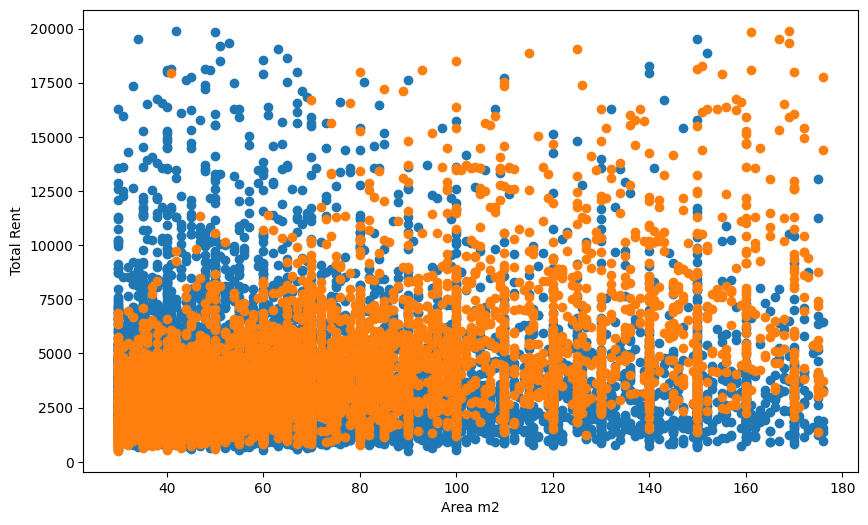

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(x=X, y=y, label='Pop')
plt.scatter(x=X_train, y=y_train, label='train')
plt.xlabel('Area m2')
plt.ylabel('Total Rent')
plt.show()

### Feature Scaling with Normalization

In [17]:
X_min = np.min(X_train)
X_max = np.max(X_train)

X_train_scaled = (X_train - X_min) / (X_max - X_min)

### Calculating best alpha value while using gradient descent to find best values for w and b

In [18]:
w = np.zeros(X_train.shape[1])
b = 0
n_iters = 1000

In [19]:
alpha = 0.001
cost = compute_linear_reg_cost(X_train_scaled, y_train, w, b)
while True:
    try:
        print(f"\n alpha: {alpha}")
        w_temp, b_temp = compute_gradient_descent(X_train_scaled, y_train, w, b, alpha, compute_linear_reg_gradient, compute_linear_reg_cost, n_iters)
        cost_temp = compute_linear_reg_cost(X_train_scaled, y_train, w_temp, b_temp)
        if cost_temp < cost:
            w, b, cost = w_temp, b_temp, cost_temp
            alpha = round((alpha * 3), 3)
        else:
            alpha = round((alpha / 3), 3)
            break
    except OverflowError as e:
        print("Cost value too large.")
        break
print(f"Best alpha value: {alpha}")


 alpha: 0.001
Iteration n: 0, w_values:[1.26795952], b_value:3.6228621462594566, total_cost:9795495.563792014
Iteration n: 100, w_values:[122.63875112], b_value:346.6108522988715, total_cost:8471221.119048033
Iteration n: 200, w_values:[233.99849518], b_value:654.0172496253663, total_cost:7401774.037944099
Iteration n: 300, w_values:[336.35538378], b_value:929.4687284861595, total_cost:6537906.370947826
Iteration n: 400, w_values:[430.61499186], b_value:1176.2226174067323, total_cost:5839889.875400516
Iteration n: 500, w_values:[517.59072721], b_value:1397.204512332165, total_cost:5275675.82140901
Iteration n: 600, w_values:[598.01321626], b_value:1595.0420594491159, total_cost:4819410.514167552
Iteration n: 700, w_values:[672.53873406], b_value:1772.0952976561564, total_cost:4450237.77138812
Iteration n: 800, w_values:[741.75677576], b_value:1930.4839110385656, total_cost:4151332.886336129
Iteration n: 900, w_values:[806.19685701], b_value:2072.1117060244, total_cost:3909123.32943469

In [20]:
print(w, b, alpha)

[5985.5751681] 2040.137832705036 0.729


### Multiple prediction vector ($\hat{y}$)

In [21]:
def multi_predict(X, w, b):
    """
    INPUT:
    X (np.ndarray(m,n)): data examples, m:number of training ex, n:number of features
    w (np.ndarray, Scalar): parameters values of the model
    b (Scalar): parameter value of the model
    OUTPUT:
    y_vec (np.ndarray(m,)): predictions based on X, w, b
    """
    m = X.shape[0]
    y_vec = np.zeros(X.shape[0])
    for i in range(m):
        y_vec[i] = np.dot(X[i], w) + b

    return y_vec

## Predicting with data test

In [22]:
y_hat = multi_predict(X_train_scaled, w, b)

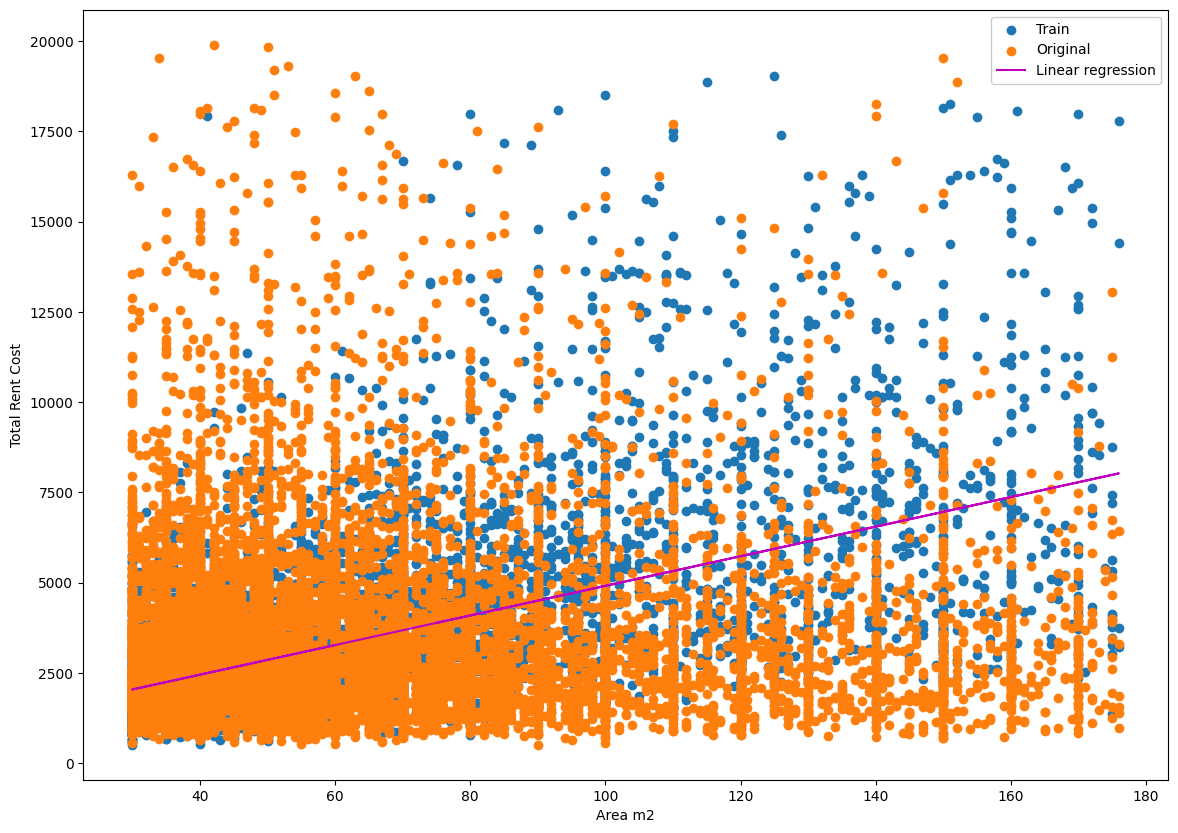

In [23]:
plt.figure(figsize=(14, 10))
plt.scatter(X_train, y_train, label='Train')
plt.scatter(X, y, label='Original')
plt.plot(X_train, y_hat, c='m', label='Linear regression')
plt.xlabel('Area m2')
plt.ylabel('Total Rent Cost')
plt.legend(loc='upper right', framealpha=1)
plt.show()

### Singular scalar predict

In [24]:
def single_value_predict(X, w, b):
    """
    INPUT:
    X (np.ndarray(,n)): data example, n:number of features
    w (np.ndarray, Scalar): parameters values of the model
    b (Scalar): parameter value of the model
    OUTPUT:
    y_sca (Scalar): prediction based on X, w, b
    """
    
    y_sca = np.dot(X, w) + b
    y_sca = y_sca[0]
    return y_sca

### So, How much would it cost to rent a 40 square meters property?

In [26]:
X_example = 40
X_example_scaled = (X_example - X_min) / (X_max - X_min)
value = single_value_predict(X_example_scaled, w, b)
print(f'R${round(value, 2)}')

R$2450.11


### Function to predict a price based on property size

In [27]:
print(f'Rent value = ({round(w[0], 2)} * size property(normalized)) + {round(b, 2)}')

Rent value = (5985.58 * size property(normalized)) + 2040.14
